<a href="https://colab.research.google.com/github/rtajeong/M4_2026/blob/main/lab_62a_word_vector_rev3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Word Embedding
- express words using vectors
- vectors are trained

# Word2Vec - English
- https://machinelearningmastery.com/develop-word-embeddings-python-gensim/
- good tutorial at https://rare-technologies.com/word2vec-tutorial/#training

- calling Word2Vec(sentences, iter=1) will run two passes over the sentences iterator (or, in general iter+1 passes; default iter=5).
  - The first pass collects words and their frequencies to build an internal dictionary tree structure.
  - The second and subsequent passes train the neural model.

In [2]:
!pip install gensim

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 64.7 MB/s eta 0:00:00


In [4]:
from gensim.models import Word2Vec
# define training data
sentences = [['this', 'is', 'the', 'first', 'sentence', 'for', 'word2vec'],
			['this', 'is', 'the', 'second', 'sentence'],
			['yet', 'another', 'sentence'],
			['one', 'more', 'sentence'],
			['and', 'the', 'final', 'sentence']]
# train model
model = Word2Vec(sentences, min_count=1, vector_size=5)
# summarize the loaded model
print(model)

Word2Vec<vocab=14, vector_size=5, alpha=0.025>


In [12]:
# summarize vocabulary (to see learned vocabulary of tokens (words) )
print(model.wv.key_to_index)

words = list(model.wv.key_to_index.keys())
print(words)


{'sentence': 0, 'the': 1, 'is': 2, 'this': 3, 'final': 4, 'and': 5, 'more': 6, 'one': 7, 'another': 8, 'yet': 9, 'second': 10, 'word2vec': 11, 'for': 12, 'first': 13}
['sentence', 'the', 'is', 'this', 'final', 'and', 'more', 'one', 'another', 'yet', 'second', 'word2vec', 'for', 'first']


In [28]:
# access vector for words
print(model.wv[['sentence', 'word2vec']])

# save model
model.save('model.bin')

# load model
new_model = Word2Vec.load('model.bin')

print(new_model)

[[-0.01072454  0.00472863  0.10206699  0.18018547 -0.186059  ]
 [-0.08924353  0.09035001 -0.1357392  -0.07096978  0.18797016]]
Word2Vec<vocab=14, vector_size=5, alpha=0.025>


In [29]:
model.wv[['sentence', 'word2vec']]

array([[-0.01072454,  0.00472863,  0.10206699,  0.18018547, -0.186059  ],
       [-0.08924353,  0.09035001, -0.1357392 , -0.07096978,  0.18797016]],
      dtype=float32)

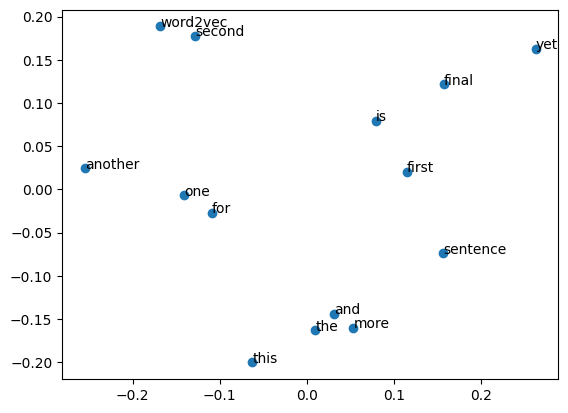

In [30]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
%matplotlib inline

X = model.wv.vectors  # Get all word vectors
pca = PCA(n_components=2)
result = pca.fit_transform(X)

plt.scatter(result[:, 0], result[:, 1])
words = model.wv.index_to_key # Get the list of words (vocabulary)
for i, word in enumerate(words):
    plt.annotate(word, xy=(result[i, 0], result[i, 1]))
plt.show()

In [31]:
# you can continue training it later
model.train([["hello", "world"]], total_examples=1, epochs=1)

(0, 2)

# Using pre-trained Word2Vec model
- GoogleNews-vectors-negative300.bin
- Korean version "ko.vec" available

In [32]:
import gensim
from gensim.models import word2vec
from gensim.models import KeyedVectors
from sklearn.metrics.pairwise import cosine_similarity

In [ ]:
!wget -P ./ -c "https://s3.amazonaws.com/dl4j-distribution/GoogleNews-vectors-negative300.bin.gz"

In [ ]:
!ls -l

In [ ]:
EMBEDDING_FILE = './GoogleNews-vectors-negative300.bin.gz'
word_vectors = KeyedVectors.load_word2vec_format(EMBEDDING_FILE, binary=True)

In [ ]:
word_vectors.vectors.shape

In [ ]:
v_apple = word_vectors["apple"]
v_mango = word_vectors["mango"]
print(v_apple.shape)
print(v_mango.shape)
cosine_similarity([v_mango],[v_apple])

In [ ]:
word_vectors.most_similar(["apple"]), word_vectors.most_similar("tiger")

- king - man + woman

In [ ]:
word_vectors.most_similar(positive=["king","Woman"], negative=["man"])

In [ ]:
words = ["soccer", "football", "baseball", "volleyball", "basketball", "tennis",
         "persimmon", "softball", "apple", "hockey", "orange", "pear", "strawberry",
         "eat", "drink", "taste", "talk", "speak", "study", "research", "have", "take"]
mat = word_vectors[words]
mat.shape

In [ ]:
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
pca = PCA(n_components=2)
xys = pca.fit_transform(mat)
xs = xys[:,0]
ys = xys[:,1]

plt.figure(figsize=(12,6))
plt.scatter(xs, ys)

for i, word in enumerate(words):
    plt.annotate(word, xy=(xs[i], ys[i]), rotation=30)
plt.show()

- Pre-trained Word2Vec
  - for english: (about 3 GB, and takes long to download): https://code.google.com/archive/p/word2vec
  - word vectors of 30+ languages: https://github.com/Kyubyong/wordvectors

# Glove - pretrained word embedder

In [33]:
import gensim.downloader as api

glove_model = api.load('glove-twitter-25')
sample_glove_embedding=glove_model['computer']

[==================================================] 100.0% 104.8/104.8MB downloaded


In [ ]:
sample_glove_embedding

In [40]:
words = ["soccer", "football", "baseball", "volleyball", "basketball", "tennis", "pingpong",
         "persimmon", "softball", "apple", "hockey", "orange", "pear", "strawberry", "blueberry",
         "eat", "drink", "taste", "talk", "speak", "study", "research", "have", "take",
         "korea", "usa", "china", "japan", "canada", "iran", "iraque"]
mat = glove_model[words]
mat.shape

(31, 25)

In [36]:
import matplotlib.pyplot as plt

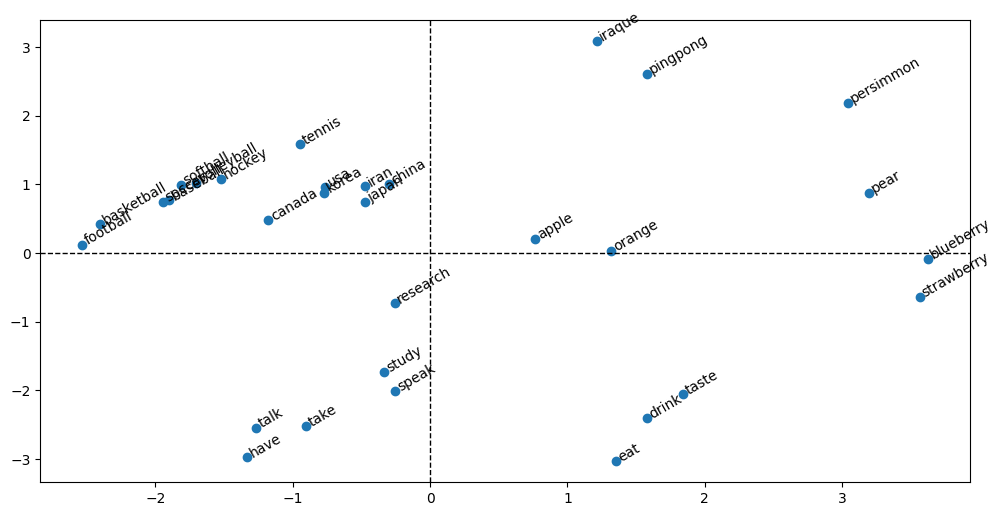

In [41]:
from sklearn.decomposition import PCA
pca = PCA(n_components=2)
xys = pca.fit_transform(mat)
xs = xys[:,0]
ys = xys[:,1]

plt.figure(figsize=(12,6))
plt.axhline(y=0, color='black', linestyle='--', linewidth=1)
plt.axvline(x=0, color='black', linestyle='--', linewidth=1)
plt.scatter(xs, ys)

for i, word in enumerate(words):
    plt.annotate(word, xy=(xs[i], ys[i]), rotation=30)
plt.show()

# difference between Glove and Word2Vec
- Both word2vec and glove enable us to represent a word in the form of a vector (often called embedding). They are the two most popular algorithms for word embeddings that bring out the semantic similarity of words that captures different facets of the meaning of a word.
- Word2vec embeddings are based on training a shallow feedforward neural network while glove embeddings are learnt based on matrix factorization techniques.
- Glove model is based on leveraging global word to word co-occurance counts leveraging the entire corpus. Word2vec on the other hand leverages co-occurance within local context (neighbouring words).
- In practice, however, both these models give similar results for many tasks. ​_Factors such as the dataset on which these models are trained, length of the vectors and so on seem to have a bigger impact than the models themselves. For instance, if I am using these models to derive  the features for a medical application, I can significantly improve performance by training on dataset from the medical domain.

# Doc2Vec
- extension of Word2Vec
- https://lovit.github.io/nlp/representation/2018/03/26/word_doc_embedding/
- doc2vec을 만드는 과정에서 word2vec 모델이 필요하므로 필연적으로 word2vec도 생성

In [42]:
#Import all the dependencies
from gensim.models.doc2vec import Doc2Vec, TaggedDocument
from nltk.tokenize import word_tokenize

In [43]:
import nltk
nltk.download('punkt')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.


True

In [46]:
import nltk
nltk.download('punkt_tab')

data = ["I love machine learning. Its awesome.",
        "I love coding in python",
        "I love building chatbots",
        "they chat amagingly well"]

tagged_data = [TaggedDocument(words=word_tokenize(_d.lower()), tags=[str(i)]) for i, _d in enumerate(data)]

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


In [47]:
tagged_data

[TaggedDocument(words=['i', 'love', 'machine', 'learning', '.', 'its', 'awesome', '.'], tags=['0']),
 TaggedDocument(words=['i', 'love', 'coding', 'in', 'python'], tags=['1']),
 TaggedDocument(words=['i', 'love', 'building', 'chatbots'], tags=['2']),
 TaggedDocument(words=['they', 'chat', 'amagingly', 'well'], tags=['3'])]

In [48]:
max_epochs = 100
vec_size = 5
alpha = 0.025

model = Doc2Vec(vector_size=vec_size,
                alpha=alpha,
                min_alpha=0.00025,
                min_count=1,
                dm =1)    # dm=1:preserves word order, 0: do not preserve order

model.build_vocab(tagged_data)   # build a vocabulary

In [49]:
model.corpus_count, model.epochs

(4, 10)

In [50]:
for epoch in range(max_epochs):
    model.train(tagged_data,
                total_examples=model.corpus_count,
                epochs=model.epochs)

    model.alpha -= 0.0002           # decrease the learning rate
    model.min_alpha = model.alpha   # fix the learning rate, no decay

model.save("d2v.model")

In [52]:
model= Doc2Vec.load("d2v.model")

In [53]:
# to infer a new document vector
test_data = word_tokenize("I love chatbots".lower())
new_v = model.infer_vector(test_data)
print(test_data)
print("new vector inferred: ", new_v)

['i', 'love', 'chatbots']
new vector inferred:  [-0.0427134  -0.07817195 -0.09423335  0.04496737 -0.04926967]


In [54]:
model.wv.similar_by_vector(new_v)

[('.', 0.8086113333702087),
 ('love', 0.667360782623291),
 ('machine', 0.6346994638442993),
 ('awesome', 0.6025295853614807),
 ('its', 0.5774157047271729),
 ('chatbots', 0.5244691967964172),
 ('building', 0.4621903598308563),
 ('learning', 0.43449530005455017),
 ('i', 0.3958684206008911),
 ('python', 0.3446473777294159)]

In [55]:
# to find most similar doc using tags (it uses word-vectors.)
similar_doc = model.docvecs.most_similar('1')
print(similar_doc)

[('2', 0.7482127547264099), ('0', 0.5655904412269592), ('3', 0.47105374932289124)]


/tmp/ipykernel_2019/1803565443.py:2: DeprecationWarning: Call to deprecated `docvecs` (The `docvecs` property has been renamed `dv`.).
  similar_doc = model.docvecs.most_similar('1')


In [56]:
# to find vector of doc in training data using tags or in other words, printing the vector of document at index 1 in training data
print(model.docvecs['1'])

[-0.40079355 -1.5227454  -1.0852035  -1.7978667   0.2665331 ]


/tmp/ipykernel_2019/1723043646.py:2: DeprecationWarning: Call to deprecated `docvecs` (The `docvecs` property has been renamed `dv`.).
  print(model.docvecs['1'])


# Exercise (연습)

In [59]:
!pip install konlpy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 19.4/19.4 MB 98.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 438.5/438.5 kB 43.5 MB/s eta 0:00:00


In [61]:
from konlpy.tag import Kkma
kkma = Kkma()
# KoNLPy: 형태소 (뜻을 가진 최소 언어 단위) 분석
# kkma: Korean morpheme analyzer
# https://konlpy.org/ko/latest/morph/#pos-tagging-with-konlpy
print(kkma.sentences('네, 안녕하세요. 반갑습니다.'))
print(kkma.nouns('질문이나 건의사항은 깃헙 이슈 트래커에 남겨주세요.'))
print(kkma.pos('오류 보고는 실행환경, 에러 메세지와 함께 설명을 최대한 상세히!^^'))
# pos (part-of-speech): 품사 (명사, 동사, ...)

['네, 안녕하세요.', '반갑습니다.']
['질문', '건의', '건의사항', '사항', '깃헙', '이슈', '트래커']
[('오류', 'NNG'), ('보', 'VV'), ('고는', 'ECE'), ('실행', 'NNG'), ('환경', 'NNG'), (',', 'SP'), ('에', 'JC'), ('러', 'NNP'), ('메세지', 'NNG'), ('와', 'JKM'), ('함께', 'MAG'), ('설명', 'NNG'), ('을', 'JKO'), ('최대한', 'NNG'), ('상세히', 'MAG'), ('!', 'SF'), ('^^', 'EMO')]


---------------------------